# A Prototype of the Stabilisation Method as Demonstrated in Dutta's Article

In [95]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [96]:
pip install scipy matplotlib pandas seaborn scikit-learn sympy jupyter

Note: you may need to restart the kernel to use updated packages.


In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

### Generation of Polynomial indices
We enforce a truncation like $$ l+m+n\leq N $$

In [98]:
# Polynomial indices

def generate_hylleraas_powers(N):
    powers = []
    for l in range(N+1):
        for m in range(N+1):
            for n in range(N+1):
                if l + m + n <= N:
                    powers.append((l, m, n))
    return powers


#example
generate_hylleraas_powers(2)

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 1, 0),
 (0, 1, 1),
 (0, 2, 0),
 (1, 0, 0),
 (1, 0, 1),
 (1, 1, 0),
 (2, 0, 0)]

In [99]:
#Exponent Scaling

# k starts at 0

def generate_exponents(rho1, gamma, q):
    return np.array([rho1 * gamma**(k) for k in range(q)])

generate_exponents(1,2,8)

array([  1,   2,   4,   8,  16,  32,  64, 128])

### 4. Combine into full basis

Now we combine :

*   all (l,m,n)
*   all exponent pairs $(k_1, k_2)$

Each basis function is just a tuple of parameters for now.


The function first generates all admissible Hylleraas powers

\begin{equation}
P_N=\{(l,m,n)\in \mathbb{N}_0^3:\; l+m+n\le N\}.
\end{equation}

Thus all triples $(l,m,n)$ satisfying

\begin{equation}
l+m+n\le N
\end{equation}

are included in the basis construction.

Next, a geometric sequence of nonlinear exponents is generated according to

\begin{equation}
\rho_k=\rho_1\gamma^k,
\qquad
k=0,1,\ldots,q-1.
\end{equation}

This produces the exponent set

\begin{equation}
E=
\{\rho_1,\rho_1\gamma,\rho_1\gamma^2,\ldots,\rho_1\gamma^{q-1}\}.
\end{equation}

The function then forms all ordered pairs of exponents

\begin{equation}
(\alpha,\beta)\in E\times E.
\end{equation}

Hence

\begin{equation}
\alpha=\rho_1\gamma^{k_1},
\qquad
\beta=\rho_1\gamma^{k_2},
\end{equation}

where

\begin{equation}
k_1,k_2=0,1,\ldots,q-1.
\end{equation}

For every admissible power triple $(l,m,n)$ and every exponent pair
$(\alpha,\beta)$, one basis element is created. Therefore the complete
basis set is

\begin{equation}
\mathcal{B}
=
\Big\{
(l,m,n,\alpha,\beta):
l+m+n\le N,
\;
\alpha=\rho_1\gamma^{k_1},
\;
\beta=\rho_1\gamma^{k_2}
\Big\}.
\end{equation}

Equivalently,

\begin{equation}
\mathcal{B}
=
P_N\times E\times E.
\end{equation}

The corresponding Hylleraas basis functions are

\begin{equation}
\phi_{lmnk_1k_2}(s,t,u)
=
s^{\,l}t^{\,m}u^{\,n}
e^{-\alpha s}
e^{-\beta t},
\end{equation}

with

\begin{equation}
\alpha=\rho_1\gamma^{k_1},
\qquad
\beta=\rho_1\gamma^{k_2}.
\end{equation}

If

\begin{equation}
|P_N|
=
\#\{(l,m,n):l+m+n\le N\},
\end{equation}

denotes the number of admissible Hylleraas power triples, then the total
number of generated basis functions is

\begin{equation}
|\mathcal{B}|
=
|P_N|\,q^2.
\end{equation}

Since

\begin{equation}
|P_N|
=
\binom{N+3}{3},
\end{equation}

the basis dimension is

\begin{equation}
|\mathcal{B}|
=
\binom{N+3}{3}q^2.
\end{equation}

In [100]:
def generate_basis(N, rho1, gamma, q):
    powers = generate_hylleraas_powers(N)
    exponents = generate_exponents(rho1, gamma, q)

    basis = []

    for (l, m, n) in powers:
        for i, alpha in enumerate(exponents):
            for j, beta in enumerate(exponents):
                basis.append({
                    "l": l,
                    "m": m,
                    "n": n,
                    "alpha": alpha,
                    "beta": beta,
                    "k1": i,
                    "k2": j
                })

    return basis

#example (inspecting the basis)
N = 2
rho1 = 1.0
gamma = 2.0
q = 3

basis = generate_basis(N, rho1, gamma, q)

print("Number of basis functions:", len(basis))
print("First five basis functions:")

for b in basis[:5]:
    print(b)

Number of basis functions: 90
First five basis functions:
{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'k1': 0, 'k2': 0}
{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(2.0), 'k1': 0, 'k2': 1}
{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(4.0), 'k1': 0, 'k2': 2}
{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(2.0), 'beta': np.float64(1.0), 'k1': 1, 'k2': 0}
{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(2.0), 'beta': np.float64(2.0), 'k1': 1, 'k2': 1}


### 6. Computing the Master Integral

The exact Hylleraas integral is quite complicated, so for now we implement a numerical version so we can build the pipeline. Then we later replace it with analytic formulas.

We compute $$ I(L,M,N;A,B) = \int r_{1}^{L}r_{2}^{M}r_{12}^{N} e^{-Ar_1 - Br_2} r_1 r_2 r_{12} dr_1 dr_2 dr_{12} $$

#### Mathematical Interpretation of the Master Integral Function

The function master_integral numerically approximates the Hylleraas integral stated above

subject to the geometric constraint

\begin{equation}
|r_1-r_2|
\leq r_{12}
\leq r_1+r_2.
\end{equation}

1. Discretization of $r_1$

The continuous interval

\begin{equation}
0 \leq r_1 \leq R
\end{equation}

is replaced by a finite set of grid points

\begin{equation}
r_1^{(1)}, r_1^{(2)}, \ldots, r_1^{(n_1)}.
\end{equation}

The integral over $r_1$

\begin{equation}
\int_0^R f(r_1)\,dr_1
\end{equation}

is approximated by the Riemann sum

\begin{equation}
\sum_{i=1}^{n_1}
f(r_1^{(i)})\,\Delta r_1.
\end{equation}

2. Discretization of $r_2$

Similarly,

\begin{equation}
0 \leq r_2 \leq R
\end{equation}

is replaced by

\begin{equation}
r_2^{(1)}, r_2^{(2)}, \ldots, r_2^{(n_2)}.
\end{equation}

The integral over $r_2$

\begin{equation}
\int_0^R g(r_2)\,dr_2
\end{equation}

is approximated by

\begin{equation}
\sum_{j=1}^{n_2}
g(r_2^{(j)})\,\Delta r_2.
\end{equation}

3. Enforcement of the Triangle Inequality

For each pair $(r_1,r_2)$, the coordinate $r_{12}$ is restricted by

\begin{equation}
|r_1-r_2|
\leq
r_{12}
\leq
r_1+r_2.
\end{equation}

Hence the inner integral is

\begin{equation}
\int_{|r_1-r_2|}^{r_1+r_2}
h(r_{12})\,dr_{12}.
\end{equation}

The interval is discretized as

\begin{equation}
r_{12}^{(1)},
r_{12}^{(2)},
\dots,
r_{12}^{(n_{12})}.
\end{equation}

4. Evaluation of the Integrand

At each grid point

\begin{equation}
    \left( r_1^{(i)}, r_2^{(j)}, r_{12}^{(k)} \right),
\end{equation}

the code evaluates

\begin{equation}
    f(r_1, r_2, r_{12} = r_1^L r_2^M r_{12}^N e^{-A r_1-B r_2} r_1 r_2 r_{12}
\end{equation}

Combining powers yields

\begin{equation}
f(r_1,r_2,r_{12})=
r_1^{L+1}
r_2^{M+1}
r_{12}^{N+1}
e^{-A r_1-B r_2}.
\end{equation}

5. Formation of the Triple Sum

The exact integral

\begin{equation}
I(L,M,N;A,B) =
\int f(r_1,r_2,r_{12})
\,dr_1dr_2dr_{12}
\end{equation}

is approximated by

\begin{equation}
I(L,M,N;A,B)
\approx
\sum_{i=1}^{n_1}
\sum_{j=1}^{n_2}
\sum_{k=1}^{n_{12}}
f\!\left(
r_1^{(i)},
r_2^{(j)},
r_{12}^{(k)}
\right)
\Delta r_1
\Delta r_2
\Delta r_{12}.
\end{equation}

6. Final Approximation

Thus the function approximates

\begin{equation}
I(L,M,N;A,B) = \int_0^\infty \int_0^\infty \int_{|r_1-r_2|}^{r_1+r_2} r_1^{L+1}
r_2^{M+1}
r_{12}^{N+1}
e^{-A r_1-B r_2}
\,dr_{12}\,dr_2\,dr_1
\end{equation}

by a finite triple Riemann sum over a discretized integration domain satisfying the triangle inequality.

In [101]:
# Simple numerical integration grid
r1_vals = np.linspace(0.001, 5, 40)
r2_vals = np.linspace(0.001, 5, 40)

def master_integral(L, M, N, A, B):
    L = int(L)
    M = int(M)
    N = int(N)
    A = float(A)
    B = float(B)
    total = 0.0

    for r1 in r1_vals:
        for r2 in r2_vals:

            # r12 range from triangle inequality
            r12_min = abs(r1 - r2)
            r12_max = r1 + r2

            r12_vals = np.linspace(r12_min + 1e-6, r12_max, 20)

            for r12 in r12_vals:
                integrand = (
                    r1**L *
                    r2**M *
                    r12**N *
                    np.exp(-A*r1 - B*r2) *
                    r1 * r2 * r12   # volume element
                )
                total += integrand

    return total

In [102]:
def master_integral(L, M, N, A, B):
    L, M, N = int(L), int(M), int(N)
    A, B = float(A), float(B)

    total = 0.0

    dr1 = r1_vals[1] - r1_vals[0]
    dr2 = r2_vals[1] - r2_vals[0]

    for r1 in r1_vals:
        for r2 in r2_vals:

            r12_min = abs(r1 - r2)
            r12_max = r1 + r2

            r12_vals = np.linspace(r12_min + 1e-6, r12_max, 20)
            dr12 = (r12_max - r12_min) / 20

            for r12 in r12_vals:

                integrand = (
                    (r1 ** L) *
                    (r2 ** M) *
                    (r12 ** N) *
                    np.exp(-A * r1 - B * r2) *
                    r1 * r2 * r12
                )

                total += integrand * dr1 * dr2 * dr12

    return total

### The Overlap Matrix

In [103]:
def build_overlap_matrix(basis):
    size = len(basis)
    S = np.zeros((size, size))

    for i in range(size):
        l1, m1, n1, _, _, alpha1, beta1 = basis[i]

        for j in range(size):
            l2, m2, n2, _, _, alpha2, beta2 = basis[j]

            L = l1 + l2
            M = m1 + m2
            N = n1 + n2
            #L = int(float(l1) + float(l2))
            #M = int(float(m1) + float(m2))
            #N = int(float(n1) + float(n2))

            A = alpha1 + alpha2
            B = beta1 + beta2

            #Computing the overlap integral
            S[i, j] = master_integral(L, M, N, A, B)

    return S

In [104]:
def build_overlap_matrix(basis):
    size = len(basis)
    S = np.zeros((size, size))

    for i in range(size):
        l1, m1, n1, _, _, alpha1, beta1 = basis[i]

        for j in range(i, size):   # exploit symmetry
            l2, m2, n2, _, _, alpha2, beta2 = basis[j]

            try:
                L = int(l1) + int(l2)
                M = int(m1) + int(m2)
                N = int(n1) + int(n2)

                A = float(alpha1) + float(alpha2)
                B = float(beta1) + float(beta2)

            except ValueError:
                print(f"Problematic basis functions:")
                print(f"basis[{i}] = {basis[i]}")
                print(f"basis[{j}] = {basis[j]}")
                raise

            S[i, j] = master_integral(L, M, N, A, B)
            S[j, i] = S[i, j]   # symmetry

    return S

In [105]:
print("First basis function:", basis[0])
print("Second basis function:", basis[1])

First basis function: {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'k1': 0, 'k2': 0}
Second basis function: {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(2.0), 'k1': 0, 'k2': 1}


In [106]:
print(basis[:5])

[{'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'k1': 0, 'k2': 0}, {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(2.0), 'k1': 0, 'k2': 1}, {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(1.0), 'beta': np.float64(4.0), 'k1': 0, 'k2': 2}, {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(2.0), 'beta': np.float64(1.0), 'k1': 1, 'k2': 0}, {'l': 0, 'm': 0, 'n': 0, 'alpha': np.float64(2.0), 'beta': np.float64(2.0), 'k1': 1, 'k2': 1}]


In [107]:
#corrected overlap matrix

def build_overlap_matrix(basis):
    size = len(basis)
    S = np.zeros((size, size))

    for i in range(size):

        l1 = basis[i]['l']
        m1 = basis[i]['m']
        n1 = basis[i]['n']
        alpha1 = basis[i]['alpha']
        beta1 = basis[i]['beta']

        for j in range(i, size):

            l2 = basis[j]['l']
            m2 = basis[j]['m']
            n2 = basis[j]['n']
            alpha2 = basis[j]['alpha']
            beta2 = basis[j]['beta']

            L = l1 + l2
            M = m1 + m2
            N = n1 + n2

            A = alpha1 + alpha2
            B = beta1 + beta2

            S[i, j] = master_integral(L, M, N, A, B)

            # exploit symmetry
            S[j, i] = S[i, j]

    return S

In [108]:
basis = generate_basis(N=1, rho1=1.0, gamma=1.5, q=2)

S = build_overlap_matrix(basis)

print("Shape:", S.shape)
print("Matrix:\n", S)

Shape: (16, 16)
Matrix:
 [[0.12437161 0.06381589 0.06381589 0.03274435 0.27267237 0.12687356
  0.12687356 0.05783474 0.18527207 0.07650301 0.09506432 0.03925419
  0.18527207 0.09506432 0.07650301 0.03925419]
 [0.06381589 0.03693798 0.03274435 0.01895312 0.12687356 0.0686937
  0.05783474 0.03079626 0.07650301 0.03693825 0.03925419 0.01895326
  0.09506432 0.05502522 0.03925419 0.02272115]
 [0.06381589 0.03274435 0.03693798 0.01895312 0.12687356 0.05783474
  0.0686937  0.03079626 0.09506432 0.03925419 0.05502522 0.02272115
  0.07650301 0.03925419 0.03693825 0.01895326]
 [0.03274435 0.01895312 0.01895312 0.01097046 0.05783474 0.03079626
  0.03079626 0.01616624 0.03925419 0.01895326 0.02272115 0.01097054
  0.03925419 0.02272115 0.01895326 0.01097054]
 [0.27267237 0.12687356 0.12687356 0.05783474 0.74570573 0.31590801
  0.31590801 0.12818639 0.47036382 0.17243587 0.22453249 0.08075225
  0.47036382 0.22453249 0.17243587 0.08075225]
 [0.12687356 0.0686937  0.05783474 0.03079626 0.31590801 0.16

## Hamiltonian Matrix Construction

After constructing the overlap matrix


\begin{equation}
S_{ij}= \langle \phi_i \mid \phi_j \rangle,
\end{equation}

the next step is to construct the Hamiltonian matrix

\begin{equation}
    H_{ij} = \langle \phi_i \mid \hat H \mid \phi_j \rangle.
\end{equation}

The Ritz variational principle then leads to the generalized eigenvalue problem

\begin{equation}
HC = ESC,
\end{equation}

where

\begin{equation}
H = \left(H_{ij}\right),
\qquad
S = \left(S_{ij}\right).
\end{equation}

### The Hamiltonian Operator

For a two-electron atom, the Hamiltonian is

\begin{equation}
\hat H
=
-\frac{1}{2}\nabla_1^2
-\frac{1}{2}\nabla_2^2
-\frac{Z}{r_1}
-\frac{Z}{r_2}
+\frac{1}{r_{12}}.
\end{equation}

The Hamiltonian matrix elements may be decomposed into kinetic and potential contributions,

\begin{equation}
H_{ij}
=
T_{ij}
+
V_{ij},
\end{equation}

where

\begin{equation}
T_{ij}
=
\left\langle
\phi_i
\left|
-\frac{1}{2}\nabla_1^2
-\frac{1}{2}\nabla_2^2
\right|
\phi_j
\right\rangle
\end{equation}

and

\begin{equation}
V_{ij}
=
\left\langle
\phi_i
\left|
-\frac{Z}{r_1}
-\frac{Z}{r_2}
+\frac{1}{r_{12}}
\right|
\phi_j
\right\rangle.
\end{equation}

#### Potential Energy Matrix Elements

Consider the basis functions

\begin{equation}
\phi_i = r_1^{l_i}r_2^{m_i}r_{12}^{n_i}e^{-\alpha_i r_1-\beta_i r_2},
\end{equation}

and

\begin{equation}
\phi_j = r_1^{l_j}
r_2^{m_j}
r_{12}^{n_j}
e^{-\alpha_j r_1-\beta_j r_2}.
\end{equation}

Define

\begin{align}
L &= l_i+l_j,\\
M &= m_i+m_j,\\
N &= n_i+n_j,
\end{align}

and

\begin{align}
A &= \alpha_i+\alpha_j,\\
B &= \beta_i+\beta_j.
\end{align}

The matrix element corresponding to the electron--nucleus attraction for electron 1 is

\begin{equation}
\left\langle \phi_i
\left|
\frac{1}{r_1}
\right|
\phi_j
\right\rangle =
I(L-1,M,N;A,B),
\end{equation}

where

\begin{equation}
I(L,M,N;A,B) =
\int
r_1^L r_2^M r_{12}^N
e^{-Ar_1-Br_2}
\,r_1r_2r_{12}
\,dr_1dr_2dr_{12}.
\end{equation}

Similarly,

\begin{equation}
\left\langle
\phi_i
\left|
\frac{1}{r_2}
\right|
\phi_j
\right\rangle =
I(L,M-1,N;A,B),
\end{equation}

and

\begin{equation}
\left\langle
\phi_i
\left|
\frac{1}{r_{12}}
\right|
\phi_j
\right\rangle =
I(L,M,N-1;A,B).
\end{equation}

Therefore,

\begin{equation}
V_{ij} =
-Z\,I(L-1,M,N;A,B)
-Z\,I(L,M-1,N;A,B)
+I(L,M,N-1;A,B).
\end{equation}

In [111]:
#Potential Energy Matrix elements
def build_potential_matrix(basis, Z=2):
    size = len(basis)

    V = np.zeros((size, size))

    for i in range(size):

        l1 = basis[i]['l']
        m1 = basis[i]['m']
        n1 = basis[i]['n']
        alpha1 = basis[i]['alpha']
        beta1 = basis[i]['beta']

        for j in range(i, size):

            l2 = basis[j]['l']
            m2 = basis[j]['m']
            n2 = basis[j]['n']
            alpha2 = basis[j]['alpha']
            beta2 = basis[j]['beta']

            L = l1 + l2
            M = m1 + m2
            N = n1 + n2

            A = alpha1 + alpha2
            B = beta1 + beta2

            Vij = (-Z * master_integral(L-1, M,   N,   A, B)
                -Z * master_integral(L,   M-1, N,   A, B)
                +    master_integral(L,   M,   N-1, A, B)
            )

            V[i, j] = Vij
            V[j, i] = Vij

    return V

In [112]:
# Generate a very small basis
basis = generate_basis(N=1, rho1=1.0, gamma=1.5, q=2)

print("Basis size =", len(basis))

# Build the potential matrix
V = build_potential_matrix(basis, Z=2)

print("Potential matrix shape:", V.shape)

print("\n Potential matrix:")
print(V)

Basis size = 16
Potential matrix shape: (16, 16)

 Potential matrix:
[[-0.41784262 -0.24117892 -0.24117892 -0.1368162  -0.80906302 -0.42473979
  -0.42473979 -0.2132778  -0.52080755 -0.23446431 -0.309877   -0.13724963
  -0.52080755 -0.309877   -0.23446431 -0.13724963]
 [-0.24117892 -0.15561576 -0.1368162  -0.08706227 -0.42473979 -0.25830458
  -0.2132778  -0.12518783 -0.23446431 -0.12327639 -0.13724963 -0.07111854
  -0.309877   -0.20460092 -0.13724963 -0.08955492]
 [-0.24117892 -0.1368162  -0.15561576 -0.08706227 -0.42473979 -0.2132778
  -0.25830458 -0.12518783 -0.309877   -0.13724963 -0.20460092 -0.08955492
  -0.23446431 -0.13724963 -0.12327639 -0.07111854]
 [-0.1368162  -0.08706227 -0.08706227 -0.05476081 -0.2132778  -0.12518783
  -0.12518783 -0.07128023 -0.13724963 -0.07111854 -0.08955492 -0.04589143
  -0.13724963 -0.08955492 -0.07111854 -0.04589143]
 [-0.80906302 -0.42473979 -0.42473979 -0.2132778  -1.96406687 -0.9427643
  -0.9427643  -0.41904087 -1.20077328 -0.47585822 -0.67176958 -

In [113]:
#verifying the symmetry
print(np.allclose(V, V.T))

True


In [114]:
#An explicit sheck of the first matrix element
print(V[0,0])

-0.41784262498918257


In [115]:
#verifying that the matrix element is being assembled correctly from its three physical contributions:
b = basis[0]

L = b['l'] + b['l']
M = b['m'] + b['m']
N = b['n'] + b['n']

A = b['alpha'] + b['alpha']
B = b['beta'] + b['beta']

V1 = master_integral(L-1, M,   N,   A, B)
V2 = master_integral(L,   M-1, N,   A, B)
V12 = master_integral(L,  M,   N-1, A, B)

print("<1/r1>    =", V1)
print("<1/r2>    =", V2)
print("<1/r12>   =", V12)

print("V00 = ", -2*V1 -2*V2 + V12)


<1/r1>    = 0.12398389894378806
<1/r2>    = 0.1239838989437886
<1/r12>   = 0.0780929707859708
V00 =  -0.41784262498918257


### The Kinetic Energy Matrix

For the Hylleraas basis in context, the Laplacian operator does not produce a single Hylleraas monomial, but rather many terms with different powers of $ r_1, r_2 $ and $r_{12}$, together with some inverse powers such as $r^{-1}_{1}$ and $r^{-1}_{2}$ and some correlation terms.

In [116]:

def Laplacian_terms(phi):
    """
    Returns the monomials generated by the simplified
    radial Laplacian acting on

    r1^l r2^m r12^n exp(-alpha r1 - beta r2)

    Each term is returned as

    (coefficient, Lshift, Mshift, Nshift)
    """
    l = phi['l']
    m = phi['m']
    n = phi['n']

    alpha = phi['alpha']
    beta  = phi['beta']

    terms = []

    # ∇1² contribution

    terms.append((l*(l+1),-2,0,0))

    terms.append((-2*alpha*(l+1),-1,0,0))

    terms.append((alpha**2,0,0,0))

    # ∇2² contribution

    terms.append((m*(m+1),0,-2,0))

    terms.append((-2*beta*(m+1),0,-1,0))

    terms.append((beta**2,0,0,0))

    return terms

In [117]:
def Laplacian_terms(l, m, n, alpha, beta):

    terms = []

    terms.append((l*(l+1), -2, 0, 0))
    terms.append((-2*alpha*(l+1), -1, 0, 0))
    terms.append((alpha**2, 0, 0, 0))

    terms.append((m*(m+1), 0, -2, 0))
    terms.append((-2*beta*(m+1), 0, -1, 0))
    terms.append((beta**2, 0, 0, 0))

    return terms

In [118]:
phi = basis[0]

#terms = Laplacian_terms(phi)
terms = Laplacian_terms(phi['l'],phi['m'],phi['n'],phi['alpha'],phi['beta'])

for term in terms:
    print(term)

(0, -2, 0, 0)
(np.float64(-2.0), -1, 0, 0)
(np.float64(1.0), 0, 0, 0)
(0, 0, -2, 0)
(np.float64(-2.0), 0, -1, 0)
(np.float64(1.0), 0, 0, 0)


In [119]:
#integrate each monomial
def kinetic_element(phi_i, phi_j):

    L = phi_i['l'] + phi_j['l']
    M = phi_i['m'] + phi_j['m']
    N = phi_i['n'] + phi_j['n']

    A = phi_i['alpha'] + phi_j['alpha']
    B = phi_i['beta']  + phi_j['beta']

    total = 0.0

    terms = Laplacian_terms(phi_j)

    for coeff, dL, dM, dN in terms:

        total += coeff * master_integral(
            L + dL,
            M + dM,
            N + dN,
            A,
            B
        )
    return -0.5 * total

In [120]:
def build_kinetic_matrix(basis):

    size = len(basis)

    T = np.zeros((size,size))

    for i in range(size):

        bi = basis[i]

        for j in range(i,size):

            bj = basis[j]

            L = bi['l'] + bj['l']
            M = bi['m'] + bj['m']
            N = bi['n'] + bj['n']

            A = bi['alpha'] + bj['alpha']
            B = bi['beta'] + bj['beta']

            Tij = 0.0

            terms = Laplacian_terms(
                bj['l'],
                bj['m'],
                bj['n'],
                bj['alpha'],
                bj['beta']
            )

            for coeff,dL,dM,dN in terms:

                Tij += coeff * master_integral(
                    L+dL,
                    M+dM,
                    N+dN,
                    A,
                    B
                )

            Tij *= -0.5

            T[i,j] = Tij
            T[j,i] = Tij

    return T

In [121]:
basis = generate_basis(
    N=1,
    rho1=1.0,
    gamma=1.5,
    q=2
)

T = build_kinetic_matrix(basis)

print(T.shape)
print(T)

(16, 16)
[[0.12359618 0.07864248 0.07864248 0.04816375 0.19404494 0.10786067
  0.10786067 0.05438846 0.12418176 0.06424391 0.08639782 0.04232879
  0.12418176 0.08639782 0.06424391 0.04232879]
 [0.07864248 0.05895868 0.04832254 0.0347737  0.11740429 0.08228228
  0.0597824  0.03881411 0.04824239 0.032839   0.0341183  0.02137156
  0.08685885 0.07002813 0.04251915 0.03276719]
 [0.07864248 0.04832254 0.05895868 0.0347737  0.11740429 0.0597824
  0.08228228 0.03881411 0.08685885 0.04251915 0.07002813 0.03276719
  0.04824239 0.0341183  0.032839   0.02137156]
 [0.04816375 0.0347737  0.0347737  0.02411902 0.06517634 0.0421662
  0.0421662  0.02531397 0.03430867 0.02146347 0.02801479 0.0163616
  0.03430867 0.02801479 0.02146347 0.0163616 ]
 [0.19404494 0.11740429 0.11740429 0.06517634 0.37266389 0.17819616
  0.17819616 0.06923732 0.26197257 0.11021473 0.16892378 0.06497924
  0.26197257 0.16892378 0.11021473 0.06497924]
 [0.10786067 0.08228228 0.0597824  0.0421662  0.17819616 0.14545409
  0.0897443

In [122]:
def build_hamiltonian_matrix(T, V):
    return T + V

In [123]:
H = build_hamiltonian_matrix(T, V)

print("Shape:", H.shape)
print(H)

Shape: (16, 16)
[[-0.29424644 -0.16253644 -0.16253644 -0.08865246 -0.61501808 -0.31687913
  -0.31687913 -0.15888935 -0.39662579 -0.17022041 -0.22347917 -0.09492085
  -0.39662579 -0.22347917 -0.17022041 -0.09492085]
 [-0.16253644 -0.09665708 -0.08849366 -0.05228857 -0.30733551 -0.1760223
  -0.1534954  -0.08637371 -0.18622192 -0.09043739 -0.10313133 -0.04974698
  -0.22301814 -0.1345728  -0.09473048 -0.05678774]
 [-0.16253644 -0.08849366 -0.09665708 -0.05228857 -0.30733551 -0.1534954
  -0.1760223  -0.08637371 -0.22301814 -0.09473048 -0.1345728  -0.05678774
  -0.18622192 -0.10313133 -0.09043739 -0.04974698]
 [-0.08865246 -0.05228857 -0.05228857 -0.03064178 -0.14810146 -0.08302163
  -0.08302163 -0.04596626 -0.10294096 -0.04965506 -0.06154014 -0.02952983
  -0.10294096 -0.06154014 -0.04965506 -0.02952983]
 [-0.61501808 -0.30733551 -0.30733551 -0.14810146 -1.59140298 -0.76456814
  -0.76456814 -0.34980355 -0.93880071 -0.36564349 -0.50284581 -0.19100021
  -0.93880071 -0.50284581 -0.36564349 -0.1

In [124]:
from scipy.linalg import eigh

energies, coeffs = eigh(H, S)

print("Eigenvalues:")
print(energies)

Eigenvalues:
[-1.11232695e+02 -4.77108622e+00 -3.73653126e+00 -2.77286830e+00
 -2.14169630e+00 -2.00703184e+00 -1.42862732e+00 -6.72994342e-01
 -5.67206252e-01  4.03106755e-01  2.33553842e+00  3.92318718e+00
  1.20340132e+02  1.83202033e+02  3.18939673e+02  2.25028556e+03]


In [164]:
gamma_values = np.linspace(0.8, 3.0, 40)

all_energies = []

for gamma in gamma_values:

    #print(f"gamma = {gamma:.3f}")

    # Generate basis
    basis = generate_basis(
        N=1,
        rho1=1.0,
        gamma=gamma,
        q=2
    )

    # Build matrices
    S = build_overlap_matrix(basis)
    T = build_kinetic_matrix(basis)
    V = build_potential_matrix(basis, Z=2)

    # Hamiltonian
    H = T + V

    # Solve HC = ESC
    energies, coeffs = eigh(H, S)

    # Store eigenvalues
    all_energies.append(energies)

In [165]:
all_energies = np.array(all_energies)

print(all_energies.shape)
print(all_energies)

(40, 16)
[[-1.07757051e+04 -9.93689875e+02 -3.31233119e+02 -1.41949025e+02
  -5.45962479e+00 -2.69277642e+00 -2.02203499e+00 -1.83748803e+00
  -1.76558034e+00 -7.17351870e-01 -5.99275939e-01 -8.00768002e-02
   5.14814700e-01  3.98514179e+01  5.49549148e+02  6.53453183e+03]
 [-2.81724591e+05 -3.24766908e+04 -2.85883716e+03 -1.28839329e+03
  -3.44165266e+02 -4.15001856e+00 -2.65553150e+00 -2.09568326e+00
  -1.82251242e+00 -1.73231350e+00 -1.38086893e+00 -7.12136075e-01
  -3.92444306e-01  5.16861311e-01  9.40124506e+01  6.00060420e+02]
 [-2.06146729e+07 -4.61165978e+05 -2.89577288e+04 -1.33062753e+04
  -1.39417058e+03 -2.11670905e+01 -5.87081621e+00 -2.70218364e+00
  -2.01578227e+00 -1.80281717e+00 -1.74229683e+00 -7.26623343e-01
  -1.26679645e-01  1.13094274e+00  1.66374513e+02  4.38973940e+02]
 [-4.70727420e+09 -8.87604214e+07 -8.60901273e+06 -3.38914975e+05
  -2.84697231e+04 -7.53064766e+02 -7.54732577e+01 -2.75636572e+00
  -2.00910204e+00 -1.91930310e+00 -1.72080454e+00 -8.21128605e-0

In [157]:
print(r"\begin{longtable}{c|" + "c"*16 + "}")
print(r"\hline")
print(r"$\gamma$ & $E_1$ & $E_2$ & $E_3$ & $E_4$ & $E_5$ & $E_6$ & $E_7$ & $E_8$ & $E_9$ & $E_{10}$ & $E_{11}$ & $E_{12}$ & $E_{13}$ & $E_{14}$ & $E_{15}$ & $E_{16}$ \\")
print(r"\hline")

for g, row in zip(gamma_values, all_energies):
    entries = [f"{x:.3f}" for x in row]
    print(f"{g:.3f} & " + " & ".join(entries) + r" \\")

print(r"\hline")
print(r"\end{longtable}")

\begin{longtable}{c|cccccccccccccccc}
\hline
$\gamma$ & $E_1$ & $E_2$ & $E_3$ & $E_4$ & $E_5$ & $E_6$ & $E_7$ & $E_8$ & $E_9$ & $E_{10}$ & $E_{11}$ & $E_{12}$ & $E_{13}$ & $E_{14}$ & $E_{15}$ & $E_{16}$ \\
\hline
0.800 & -10775.705 & -993.690 & -331.233 & -141.949 & -5.460 & -2.693 & -2.022 & -1.837 & -1.766 & -0.717 & -0.599 & -0.080 & 0.515 & 39.851 & 549.549 & 6534.532 \\
0.856 & -281724.591 & -32476.691 & -2858.837 & -1288.393 & -344.165 & -4.150 & -2.656 & -2.096 & -1.823 & -1.732 & -1.381 & -0.712 & -0.392 & 0.517 & 94.012 & 600.060 \\
0.913 & -20614672.933 & -461165.978 & -28957.729 & -13306.275 & -1394.171 & -21.167 & -5.871 & -2.702 & -2.016 & -1.803 & -1.742 & -0.727 & -0.127 & 1.131 & 166.375 & 438.974 \\
0.969 & -4707274204.933 & -88760421.379 & -8609012.735 & -338914.975 & -28469.723 & -753.065 & -75.473 & -2.756 & -2.009 & -1.919 & -1.721 & -0.821 & 1.424 & 4.500 & 5.642 & 8115.193 \\
1.026 & -12286.086 & -8.253 & -7.251 & -4.648 & -2.594 & -1.943 & -1.733 & -1.628 & -0.4

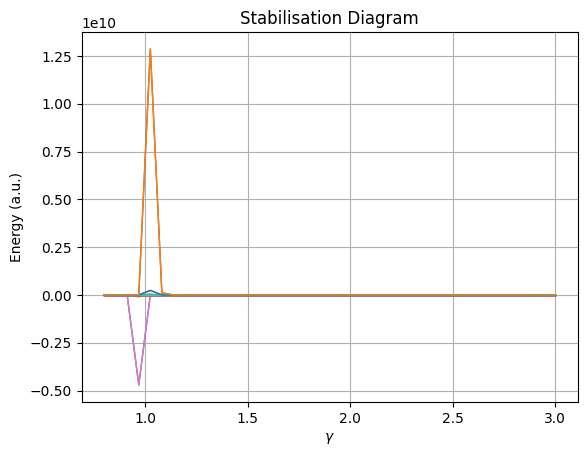

In [168]:
for n in range(min(40, n_states)):
    plt.plot(
        gamma_values,
        all_energies[:, n],
        lw=1
    )
n_states = all_energies.shape[1]

for n in range(n_states):
    plt.plot(
        gamma_values,
        all_energies[:, n],
        lw=1
    )

plt.xlabel(r'$\gamma$')
plt.ylabel('Energy (a.u.)')
plt.title('Stabilisation Diagram')
plt.grid(True)
plt.show()

In [ ]:
for n in range(min(10, n_states)):
    plt.plot(
        gamma_values,
        all_energies[:, n],
        lw=1
    )

In [135]:
np.save(
    "stabilisation_energies.npy",
    all_energies
)

In [136]:
np.savetxt(
    "stabilisation_energies.txt",
    all_energies
)

In [150]:
tol = 1e-1

indices = np.where(np.abs(slopes) < tol)[0]

slopes = np.gradient(all_energies[:, n],gamma_values)

if len(indices) > 0:
    k = indices[0]

    E_res = all_energies[k, n]
    gamma_res = gamma_values[k]

    print("Resonance energy:", E_res)
    print("Gamma:", gamma_res)
else:
    print("No stationary point found.")

E_res = all_energies[k, n]
gamma_res = gamma_values[k]

No stationary point found.


NameError: name 'k' is not defined

In [149]:
print(indices)
print(len(indices))

[]
0


In [151]:
slopes = np.gradient(
    all_energies[:, n],
    gamma_values
)

k = np.argmin(np.abs(slopes))

E_res = all_energies[k, n]
gamma_res = gamma_values[k]

print("Resonance energy =", E_res)
print("gamma =", gamma_res)
print("minimum slope =", slopes[k])

Resonance energy = 0.40376423737007855
gamma = 1.476923076923077
minimum slope = -0.18926151241558653
